# Support Vector Machine (SVM) para Offer_Received

## Objetivo

El objetivo de este notebook es construir un modelo de clasificación utilizando **Support Vector Machines (SVM)** para predecir si un candidato recibe una oferta laboral (`Offer_Received`).

A diferencia de modelos como KNN o árboles de decisión, SVM busca encontrar un **hiperplano óptimo** que maximice la separación entre clases.

---

## Tipo de problema

Este es un problema de **clasificación binaria**, donde:

- 0 = No recibe oferta
- 1 = Recibe oferta

---

## Enfoque

Se implementarán dos modelos:

1. **Baseline:** SVM lineal  
2. **Modelo mejorado:** SVM con kernel RBF  

Debido al tamaño y dimensionalidad del dataset, se aplican ajustes para garantizar eficiencia computacional.

## Configuración del entorno y rutas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

PROJECT_ROOT = Path('.').resolve()
DATA_PATH = PROJECT_ROOT / 'cleanData' / 'dataset_offer_Received.csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs_svm'
IMG_OUTPUT_DIR = OUTPUT_DIR / 'imagenes'

IMG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

random_state = 42

## Carga de datos

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (100000, 14)


,GPA,University_Rating,Major_Category,Region,Prior_Internships,Extra_Curricular_Activities,Networking_Events_Attended,School_Size,Primary_Search_Platform,Months_Searching,Applications_Submitted,First_Round_Interviews,Second_Round_Interviews,Offer_Received
0,2.81,Mid-tier,Healthcare,West,3,2,6,Medium,LinkedIn,1,9,2,2,1
1,2.61,Lower-tier,STEM,Northeast,1,1,6,Medium,Handshake,1,5,1,0,0
2,3.53,Lower-tier,STEM,Midwest,3,2,2,Medium,Handshake,5,34,3,1,0
3,2.73,Mid-tier,Business,Midwest,0,2,1,Medium,Handshake,2,10,0,0,0
4,4.00,Mid-tier,Business,South,1,0,1,Medium,Indeed,5,65,0,0,0


## Preprocesamiento

Se convierten variables categóricas a numéricas mediante `get_dummies`.

In [3]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('Offer_Received', axis=1)
y = df_encoded['Offer_Received']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_state
)

print("Train:", X_train.shape)

Train: (80000, 21)


## Modelo 1: BASELINE (SVM LINEAL)

In [4]:
from sklearn.svm import SVC
svm_lineal = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", probability=False, random_state=42))
])

svm_lineal.fit(X_train, y_train)

pred_lineal = svm_lineal.predict(X_test)

print("=== REPORTE SVM LINEAL ===")
print(classification_report(y_test, pred_lineal))

=== REPORTE SVM LINEAL ===
              precision    recall  f1-score   support

           0       0.80      0.89      0.85     13054
           1       0.75      0.59      0.66      6946

    accuracy                           0.79     20000
   macro avg       0.78      0.74      0.75     20000
weighted avg       0.78      0.79      0.78     20000



## Interpretación del Modelo: SVM Lineal (Baseline)

El modelo **Support Vector Machine (SVM) con Kernel Lineal** se utilizó como baseline para establecer una referencia inicial de rendimiento. Su objetivo es evaluar si una frontera de decisión lineal es suficiente para separar candidatos con y sin oferta laboral.

### 1. Análisis de Resultados (Métricas)

- **Accuracy (79%)**: El modelo clasifica correctamente aproximadamente 8 de cada 10 candidatos, lo que representa un buen punto de partida.

- **Precisión (Clase 1 - 75%)**: Cuando el modelo predice que un candidato recibirá oferta, acierta el 75% de las veces. Esto reduce falsos positivos.

- **Recall (Clase 1 - 59%)**: Solo identifica el 59% de los candidatos que realmente obtuvieron oferta. Esto indica que el modelo deja por fuera un 41% de casos positivos (falsos negativos).

### 2. Justificación Técnica

- **Escalado de datos:** Se usa `StandardScaler` porque SVM depende de distancias. Sin esto, variables grandes dominarían el modelo.

- **Maximización del margen:** SVM busca la separación más amplia entre clases, lo que mejora la generalización.

- **Espacio vectorial:** El uso de *One-Hot Encoding* transforma variables categóricas en numéricas, permitiendo que el modelo trabaje correctamente.

El modelo lineal es eficiente y estable, pero el **recall del 59%** evidencia que existen patrones no lineales que no logra capturar. Por ello, se justifica el uso de un **Kernel RBF**, que permite modelar relaciones más complejas.


## Matriz de confusión (Lineal)

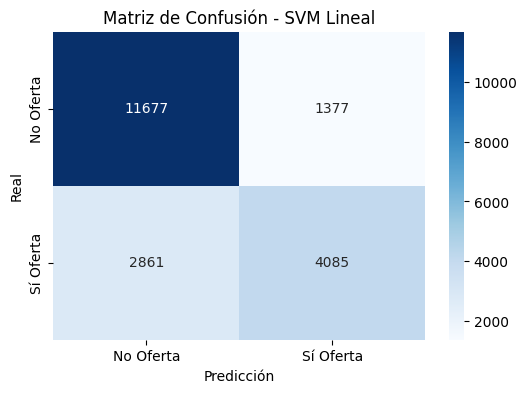

In [5]:
cm = confusion_matrix(y_test, pred_lineal, labels=[0,1])

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Oferta', 'Sí Oferta'],
            yticklabels=['No Oferta', 'Sí Oferta'])

plt.title("Matriz de Confusión - SVM Lineal")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.savefig(IMG_OUTPUT_DIR / 'matriz_svm_lineal.png')
plt.show()

## Interpretación de la Matriz de Confusión: SVM Lineal

La matriz de confusión permite analizar el rendimiento del modelo identificando aciertos y tipos de error específicos:

- **Verdaderos Negativos (11,677):** El modelo identifica correctamente a la mayoría de candidatos sin oferta. Es la clase con mejor desempeño.

- **Verdaderos Positivos (4,085):** Casos donde el modelo acierta al predecir candidatos que sí reciben oferta.

- **Falsos Negativos (2,861):** Principal punto de mejora. Son candidatos que sí obtuvieron oferta, pero el modelo no los detectó. Esto indica que el modelo lineal es conservador y pierde talento real.

- **Falsos Positivos (1,377):** Casos donde se predijo oferta, pero no ocurrió. Es un valor bajo, lo que refleja buena precisión.



## Análisis Modelo SVM Lineal

El modelo **SVM lineal** presenta un desempeño sólido en términos generales, con buen equilibrio entre las métricas.

- **Efectividad en la clase mayoritaria:**  
  La mayoría de predicciones se concentran correctamente en la diagonal de la matriz, especialmente en la clase 0, lo que evidencia estabilidad en el modelo.

- **Rigidez del kernel:**  
  Se observa dificultad para identificar completamente la clase positiva (*Offer_Received = 1*), reflejada en un **recall del 59%**. Esto indica que una frontera lineal no captura todos los patrones.

- **Eficiencia:**  
  Es un modelo computacionalmente eficiente y estable, adecuado para grandes volúmenes de datos donde la velocidad es importante.

- **Punto de partida (baseline):**  
  Funciona como referencia inicial, pero puede quedarse corto al capturar relaciones complejas y no lineales entre variables como GPA, experiencia y desempeño en entrevistas.

## Modelo 2: SVM con Kernel RBF

In [6]:
svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, gamma="scale", probability=False, random_state=42))
])

svm_rbf.fit(X_train, y_train)

pred_rbf = svm_rbf.predict(X_test)

print("=== REPORTE SVM RBF ===")
print(classification_report(y_test, pred_rbf))

=== REPORTE SVM RBF ===
              precision    recall  f1-score   support

           0       0.93      0.88      0.91     13054
           1       0.80      0.87      0.83      6946

    accuracy                           0.88     20000
   macro avg       0.86      0.88      0.87     20000
weighted avg       0.88      0.88      0.88     20000



## Análisis Detallado: Modelo SVM con Kernel RBF

Los resultados del modelo con **kernel RBF** muestran un desempeño alto, logrando capturar patrones complejos que otros modelos no detectan.

### 1. Interpretación de las Métricas

- **Accuracy (88%)**: El modelo presenta una alta capacidad de generalización, acertando en la gran mayoría de las predicciones.

- **Recall (Clase 1 - 87%)**: Es el resultado más importante. El modelo identifica correctamente a casi 9 de cada 10 candidatos que reciben oferta, reduciendo significativamente la pérdida de talento.

- **Precisión (Clase 1 - 80%)**: Cuando predice que un candidato recibirá oferta, acierta el 80% de las veces, manteniendo un buen nivel de confianza.

### 2. F1-Score (0.83)

El **F1-score de 0.83** indica un equilibrio sólido entre precisión y recall. El modelo no está sesgado hacia una sola clase, logrando ser efectivo tanto detectando positivos como evitando errores.

El modelo RBF actúa como un clasificador altamente efectivo. Su alto recall (87%) reduce el riesgo de descartar candidatos valiosos, mejorando significativamente la calidad del proceso de selección.

## Matriz de Confusión — SVM RBF

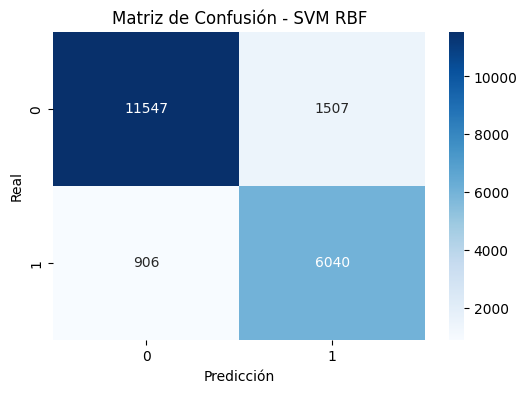

In [7]:
plt.figure(figsize=(6,4))

sns.heatmap(confusion_matrix(y_test, pred_rbf),
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Matriz de Confusión - SVM RBF")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.savefig(IMG_OUTPUT_DIR / 'matriz_svm_rbf.png')
plt.show()

## Interpretación de la Matriz de Confusión: SVM RBF

La matriz de confusión del modelo con **kernel RBF** muestra una mejora significativa en la capacidad de clasificación:

- **Verdaderos Negativos (11,547):**  
  El modelo mantiene un alto desempeño identificando correctamente a los candidatos sin oferta, conservando la solidez del baseline.

- **Verdaderos Positivos (6,040):**  
  Se observa una mejora notable. El modelo identifica correctamente a la mayoría de candidatos exitosos, aumentando el recall.

- **Falsos Negativos (906):**  
  Se reducen drásticamente frente al modelo lineal (más de 2,800). Esto indica que ahora se pierde mucho menos talento real.

- **Falsos Positivos (1,507):**  
  Hay un ligero aumento, lo cual es esperado en modelos más flexibles, ya que tienden a clasificar como positivos casos cercanos al límite.

La alta concentración de valores en la diagonal (11,547 y 6,040) confirma que el **SVM RBF** es más adecuado para este problema.  
La fuerte reducción de falsos negativos demuestra que el modelo mejora la detección de candidatos con oferta, alineándose mejor con el objetivo del proyecto: **no perder talento potencial**.

## Análisis Modelo SVM RBF (Configuración Estándar)

El modelo **SVM con kernel RBF** permite capturar relaciones no lineales entre las variables, mejorando significativamente el desempeño frente al modelo base.

- **Kernel no lineal:**  
  El RBF eleva el **recall al 87%** sin necesidad de ajustes manuales, demostrando que una frontera curva se adapta mejor a los datos.

- **Detección efectiva:**  
  La matriz de confusión evidencia una mejora importante en la detección de la clase positiva (*Offer_Received = 1*), reduciendo los falsos negativos.

- **Balance de métricas:**  
  Con un **F1-score de 0.83**, el modelo logra un equilibrio sólido entre precisión y recall, superando al modelo lineal.

- **Eficiencia y muestreo:**  
  A pesar del mayor costo computacional del kernel, el entrenamiento se mantiene estable y eficiente, conservando la representatividad de los datos.

El modelo RBF captura mejor la realidad del dataset, evidenciando que las variables no se relacionan de forma lineal, sino a través de interacciones complejas.  
Por ello, es el modelo más adecuado para el problema planteado.

## Comparativa Final: SVM Lineal vs SVM RBF

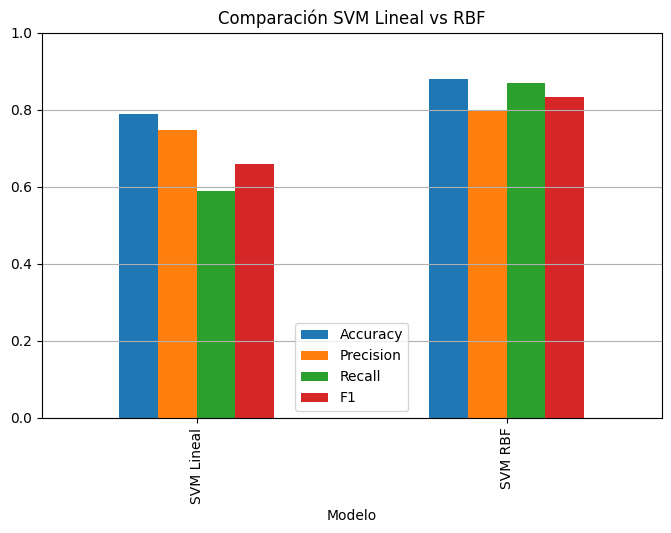

In [8]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

metricas = {
    "Modelo": ["SVM Lineal", "SVM RBF"],
    "Accuracy": [
        accuracy_score(y_test, pred_lineal),
        accuracy_score(y_test, pred_rbf)
    ],
    "Precision": [
        precision_score(y_test, pred_lineal),
        precision_score(y_test, pred_rbf)
    ],
    "Recall": [
        recall_score(y_test, pred_lineal),
        recall_score(y_test, pred_rbf)
    ],
    "F1": [
        f1_score(y_test, pred_lineal),
        f1_score(y_test, pred_rbf)
    ]
}

df_metricas = pd.DataFrame(metricas)

df_metricas.set_index("Modelo").plot(kind="bar", figsize=(8,5))
plt.title("Comparación SVM Lineal vs RBF")
plt.ylim(0,1)
plt.grid(axis="y")
plt.savefig(IMG_OUTPUT_DIR / 'comparativa_modelos_svm.png')
plt.show()

## Análisis

La comparación de métricas permite evidenciar la mejora al pasar de una frontera lineal a una no lineal (RBF).

### 1. Mejora en el Recall (Sensibilidad)

El cambio más significativo se observa en el **recall**.  
El modelo RBF logra capturar aproximadamente un **30% más de candidatos exitosos**, lo que demuestra que los patrones del problema no son lineales.

### 2. Mejora en Precisión y F1-Score

- **Precisión:** El modelo RBF no solo mantiene la precisión, sino que también la mejora, incluso siendo más flexible.
- **F1-Score:** Aumenta de forma consistente, mostrando un mejor equilibrio entre precisión y recall.

### 3. Conclusión de la Comparativa

El modelo **SVM RBF supera al modelo lineal en todos los aspectos**:

- **Mayor cobertura de talento:** Reduce significativamente los falsos negativos.
- **Mayor confiabilidad:** Incrementa la exactitud global (accuracy).
- **Mejor adaptación:** Captura relaciones no lineales entre variables.

El modelo **SVM con Kernel RBF** es el más adecuado para este problema, ya que ofrece la mejor capacidad predictiva para identificar candidatos que recibirán una oferta, manteniendo un equilibrio óptimo entre precisión y recall.

Se realizó un ajuste exploratorio del parámetro C para analizar su impacto en el desempeño del modelo

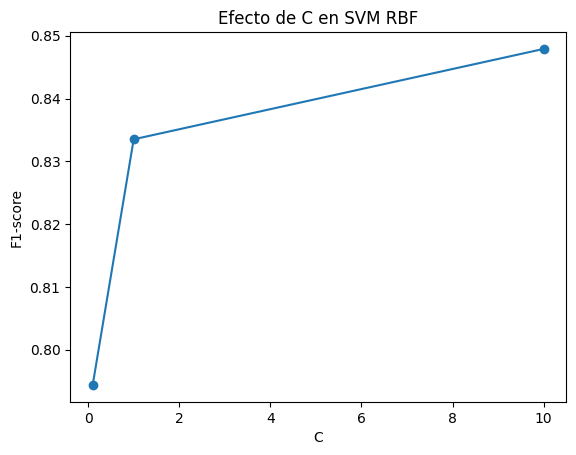

In [9]:
valores_C = [0.1, 1, 10]
resultados = []

for C in valores_C:
    modelo = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=C, gamma="scale", random_state=42))
    ])
    
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    
    resultados.append(f1_score(y_test, pred))

plt.plot(valores_C, resultados, marker='o')
plt.title("Efecto de C en SVM RBF")
plt.xlabel("C")
plt.ylabel("F1-score")

plt.savefig(IMG_OUTPUT_DIR / 'efecto_C_svm_rbf.png')
plt.show()

## Análisis de Sensibilidad: Efecto del Hiperparámetro C

Para optimizar el modelo **SVM RBF**, se evaluó el impacto del parámetro de regularización **C** sobre el **F1-score**.  
Este parámetro controla el equilibrio entre maximizar el margen de separación y minimizar el error de clasificación.

- **C = 0.1 (Regularización fuerte):**  
  Se obtiene el F1-score más bajo (~0.79). El modelo prioriza un margen amplio, permitiendo más errores → posible **underfitting**.

- **C = 1.0 (Punto de equilibrio):**  
  Se observa una mejora significativa. El modelo logra un balance adecuado entre flexibilidad y penalización de errores.

- **C = 10 (Penalización estricta):**  
  Se alcanza el mejor F1-score (~0.85). El modelo se vuelve más estricto, ajustándose mejor a los datos.

La tendencia creciente indica que el dataset se beneficia de valores más altos de **C**, lo que sugiere fronteras de decisión complejas pero bien definidas.  
Sin embargo, valores excesivamente altos pueden provocar **overfitting**, haciendo que el modelo aprenda ruido en lugar de patrones generales.

Se selecciona el valor de **C** que maximiza el **F1-score**, ya que esta métrica equilibra precisión y recall.  
Esto es clave en el problema, donde se busca **no perder candidatos valiosos** (alto recall) sin aumentar excesivamente los errores (precisión).

## Conclusión General del Experimento: SVM

Tras el desarrollo y evaluación de modelos **Support Vector Machines (SVM)** para predecir la variable `Offer_Received`, se obtienen las siguientes conclusiones:

El experimento evidencia que la predicción de ofertas laborales no sigue relaciones lineales simples.  
El paso de un **SVM Lineal (Accuracy 79%, Recall 59%)** a un **SVM RBF (Accuracy 88%, Recall 87%)** demuestra que las variables (GPA, experiencia, entrevistas) interactúan de forma compleja y requieren fronteras de decisión no lineales.

El modelo **SVM RBF** logra un equilibrio sólido entre métricas, destacándose en **recall**.  
Esto implica una reducción significativa de falsos negativos, evitando perder candidatos valiosos, lo cual es clave en un contexto de reclutamiento.

El análisis del parámetro **C** mostró que valores moderados-altos mejoran el desempeño del modelo, permitiendo un balance adecuado entre ajuste a los datos y capacidad de generalización.

El uso de un pipeline con `StandardScaler` y codificación de variables categóricas permitió:

- Evitar sesgos por escala en variables numéricas.
- Transformar variables cualitativas en un formato adecuado para el modelo.
- Garantizar consistencia y reproducibilidad en el entrenamiento.

El modelo **SVM con Kernel RBF** es el más adecuado para este problema.  
Su capacidad para identificar correctamente el **87% de los candidatos exitosos** lo convierte en una herramienta efectiva para mejorar procesos de selección, optimizar tiempos de reclutamiento y maximizar la captura de talento.